# 05 — Engine 參數 Sweep：大規模速度調研

系統化掃描 TensorRT engine 的關鍵參數組合，找出最佳推論效能配置。

| 步驟 | 內容 |
|------|------|
| 1 | 路徑設定 |
| 2 | 參數網格定義 |
| 3 | 工具函式（build + parse） |
| 4 | 執行 Sweep（可中斷續跑） |
| 5 | 結果分析（Pivot table） |
| 6 | 視覺化（Heatmap / Pareto / Throughput / Dynamic-vs-Static） |

**掃描維度：** `precision` × `builderOptimizationLevel` × `workspace_mb` × `batch_mode`

| 維度 | 選項 | GPU 要求 |
|------|------|---------|
| precision | fp32 / fp16 / bf16 / int8 / fp8 | Pascal+ / Hopper+ / Turing+ / Ada+ |
| builder_opt_level | 0, 2, 4, 5 | — |
| workspace_mb | 256, 1024 | — |
| batch_mode | static (batch=1) / dynamic (min=1, opt=4, max=8) | — |

> **注意**：`dynamic` 模式需要 ONNX 模型的 batch dim 為動態（`-1`）；若模型為靜態 batch=1，dynamic 組合會 build 失敗並自動跳過記錄。  
> **預估時間（80 組）**：每組 2–5 min → 約 2.7–6.7 小時。刪減 `PARAM_GRID` 中不需要的選項可大幅縮短。  
> **加速**：使用共用 `timingCacheFile`，後續 build 顯著加快。

## 1. 路徑設定

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src.env import *
setup_matplotlib()

SWEEP_DIR     = Path("sweep")
ENGINES_SWEEP = SWEEP_DIR / "engines"
TIMING_CACHE  = SWEEP_DIR / "timing.cache"
RESULTS_CSV   = SWEEP_DIR / "sweep_results.csv"
SWEEP_DIR.mkdir(exist_ok=True)
ENGINES_SWEEP.mkdir(exist_ok=True)

assert TRTEXEC.exists(),    f"trtexec not found: {TRTEXEC}"
assert ONNX_MODEL.exists(), f"ONNX model not found: {ONNX_MODEL}"
print(f"trtexec   : {TRTEXEC}")
print(f"ONNX model: {ONNX_MODEL}")
print(f"Output dir: {SWEEP_DIR.resolve()}")
print("Settings ready.")

Font loaded: Cubic 11  (D:\tensorrt\book\src\fonts\Cubic_11.ttf)
trtexec   : C:\Users\edisonhsieh\Downloads\TensorRT-10.8.0.43.Windows.win10.cuda-12.8\TensorRT-10.8.0.43\bin\trtexec.exe
ONNX model: C:\GPM_AI\H.onnx
Output dir: D:\tensorrt\code\notebooks\sweep
Settings ready.


## 2. 參數網格定義

| 參數 | 選項 | 說明 | GPU 要求 |
|------|------|------|---------|
| `precision` | fp32 | TRT 預設，完整精度 | 所有 GPU |
| | fp16 | 半精度浮點 | Pascal+ |
| | bf16 | Brain Float 16，指數範圍更大 | Hopper+ / Blackwell |
| | int8 | 8-bit 整數（無校準資料時用合成 PTQ） | Turing+ |
| | fp8 | 8-bit 浮點（E4M3），最小 footprint | Ada+ / Blackwell |
| `builder_opt_level` | 0, 2, 4, 5 | 0=快速 build；5=最激進優化（build 最慢）| — |
| `workspace_mb` | 256, 1024 | GPU workspace 大小（MB） | — |
| `batch_mode` | static | 固定 batch=1，與 ONNX 一致 | — |
| | dynamic | min/opt/max shapes；需 ONNX batch dim=-1 | — |

**刪除 `PARAM_GRID` 中不需要的選項可大幅縮短執行時間。**  
建議快速驗證時只保留 `["fp16", "int8"]` + `builder_opt_level=[0, 4]` + `batch_mode=["static"]`（共 4 組）。

In [2]:
import itertools
import onnx as _onnx

# ── Auto-detect ONNX input tensor name & shape ────────────────────────────
_m         = _onnx.load(str(ONNX_MODEL))
INPUT_NAME = _m.graph.input[0].name
_dims      = _m.graph.input[0].type.tensor_type.shape.dim
MODEL_C    = _dims[1].dim_value or 3
MODEL_H    = _dims[2].dim_value or 448
MODEL_W    = _dims[3].dim_value or 448
print(f"ONNX input  : '{INPUT_NAME}'  shape=[B, {MODEL_C}, {MODEL_H}, {MODEL_W}]")

# ── 動態 batch profile（build 時使用） ────────────────────────────────────
DYN_MIN_B, DYN_OPT_B, DYN_MAX_B = 1, 4, 8

# ── 參數網格 ──────────────────────────────────────────────────────────────
# 刪除不需要的選項可大幅縮短執行時間；
# dynamic batch 需要 ONNX batch dim 為動態，否則 build 失敗並自動跳過。
PARAM_GRID = {
    "precision":         ["fp32", "fp16", "bf16", "int8", "fp8"],
    "builder_opt_level": [0, 2, 4, 5],
    "workspace_mb":      [256, 1024],
    "batch_mode":        ["static", "dynamic"],
}

configs = [
    dict(zip(PARAM_GRID.keys(), values))
    for values in itertools.product(*PARAM_GRID.values())
]

print(f"\nTotal configurations : {len(configs)}")
print(f"Estimated time       : {len(configs) * 2}–{len(configs) * 5} min\n")
print(f"{'#':>3}  {'precision':>10}  {'opt_level':>9}  {'ws_mb':>6}  {'batch_mode':>12}")
print("-" * 52)
for i, c in enumerate(configs):
    print(f"{i:3d}  {c['precision']:>10}  {c['builder_opt_level']:>9}  {c['workspace_mb']:>6}  {c['batch_mode']:>12}")

ONNX input  : 'images'  shape=[B, 3, 448, 448]

Total configurations : 80
Estimated time       : 160–400 min

  #   precision  opt_level   ws_mb    batch_mode
----------------------------------------------------
  0        fp32          0     256        static
  1        fp32          0     256       dynamic
  2        fp32          0    1024        static
  3        fp32          0    1024       dynamic
  4        fp32          2     256        static
  5        fp32          2     256       dynamic
  6        fp32          2    1024        static
  7        fp32          2    1024       dynamic
  8        fp32          4     256        static
  9        fp32          4     256       dynamic
 10        fp32          4    1024        static
 11        fp32          4    1024       dynamic
 12        fp32          5     256        static
 13        fp32          5     256       dynamic
 14        fp32          5    1024        static
 15        fp32          5    1024       dynamic
 16 

## 3. 工具函式

In [3]:
import subprocess, time, re

# precision → trtexec 旗標對應
PREC_FLAGS = {
    "fp32": [],
    "fp16": ["--fp16"],
    "bf16": ["--bf16"],
    "int8": ["--int8"],
    "fp8":  ["--fp8"],
}


def _shape_str(batch: int) -> str:
    return f"{INPUT_NAME}:{batch}x{MODEL_C}x{MODEL_H}x{MODEL_W}"


def parse_trtexec(stdout: str) -> dict:
    patterns = {
        "mean_ms":        r"mean\s*=\s*([\d.]+)\s*ms",
        "median_ms":      r"median\s*=\s*([\d.]+)\s*ms",
        "p95_ms":         r"percentile\(95%\)\s*=\s*([\d.]+)\s*ms",
        "p99_ms":         r"percentile\(99%\)\s*=\s*([\d.]+)\s*ms",
        "throughput_qps": r"Throughput:\s*([\d.]+)\s*qps",
        "gpu_compute_ms": r"GPU Compute Time.*?mean\s*=\s*([\d.]+)\s*ms",
    }
    return {
        k: float(m.group(1))
        for k, pat in patterns.items()
        if (m := re.search(pat, stdout, re.IGNORECASE))
    }


def build_and_benchmark(cfg: dict, engine_path: Path) -> dict:
    is_dynamic = cfg.get("batch_mode") == "dynamic"

    cmd = [
        str(TRTEXEC),
        f"--onnx={ONNX_MODEL}",
        f"--saveEngine={engine_path}",
        f"--warmUp={WARMUP_MS}",
        f"--duration={DURATION_S}",
        f"--builderOptimizationLevel={cfg['builder_opt_level']}",
        f"--memPoolSize=workspace:{cfg['workspace_mb']}m",
        f"--timingCacheFile={TIMING_CACHE}",
        *PREC_FLAGS[cfg["precision"]],
    ]

    if is_dynamic:
        cmd += [
            f"--minShapes={_shape_str(DYN_MIN_B)}",
            f"--optShapes={_shape_str(DYN_OPT_B)}",
            f"--maxShapes={_shape_str(DYN_MAX_B)}",
            f"--shapes={_shape_str(DYN_OPT_B)}",   # benchmark at opt batch
        ]

    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    build_time_s = round(time.time() - t0, 1)

    result = {**cfg, "build_time_s": build_time_s, "success": proc.returncode == 0}
    if proc.returncode == 0:
        result.update(parse_trtexec(proc.stdout))
    else:
        result["error"] = proc.stderr[-500:].strip()
    return result


print("Helper functions loaded.")
print(f"Precision flags : { {k: v or '(none)' for k, v in PREC_FLAGS.items()} }")
print(f"Dynamic batch   : min={DYN_MIN_B}  opt={DYN_OPT_B}  max={DYN_MAX_B}")

Helper functions loaded.
Precision flags : {'fp32': '(none)', 'fp16': ['--fp16'], 'bf16': ['--bf16'], 'int8': ['--int8'], 'fp8': ['--fp8']}
Dynamic batch   : min=1  opt=4  max=8


## 4. 執行 Sweep

- 結果每組完成後即寫入 `sweep/sweep_results.csv`（可中斷後續跑）
- 已完成的 config 會自動跳過（依 `precision + opt_level + workspace_mb` 判斷）
- Engine 檔案儲存於 `sweep/engines/`

In [4]:
import pandas as pd
from tqdm.auto import tqdm


def config_key(cfg: dict) -> str:
    bm = cfg.get("batch_mode", "static")
    return f"{cfg['precision']}__opt{cfg['builder_opt_level']}__ws{cfg['workspace_mb']}__{bm}"


if RESULTS_CSV.exists():
    df_prev = pd.read_csv(RESULTS_CSV)
    # 向後相容：舊版 CSV 沒有 batch_mode 欄位
    if "batch_mode" not in df_prev.columns:
        df_prev["batch_mode"] = "static"
    done_keys = set(
        df_prev.apply(
            lambda r: f"{r.precision}__opt{int(r.builder_opt_level)}__ws{int(r.workspace_mb)}__{r.batch_mode}",
            axis=1,
        )
    )
    results = df_prev.to_dict("records")
    print(f"Resuming: {len(done_keys)} done, {len(configs) - len(done_keys)} remaining")
else:
    done_keys = set()
    results = []
    print(f"Starting fresh sweep ({len(configs)} configs)")

pbar = tqdm(configs, desc="Sweep", unit="cfg")
for i, cfg in enumerate(pbar):
    key = config_key(cfg)
    if key in done_keys:
        pbar.set_postfix_str(f"skip {key[:40]}")
        continue

    bm          = cfg.get("batch_mode", "static")
    engine_name = (
        f"H_{cfg['precision']}_opt{cfg['builder_opt_level']}"
        f"_ws{cfg['workspace_mb']}mb_{bm}.engine"
    )
    engine_path = ENGINES_SWEEP / engine_name

    pbar.set_postfix_str(
        f"{cfg['precision']} opt={cfg['builder_opt_level']} ws={cfg['workspace_mb']} {bm}"
    )
    res = build_and_benchmark(cfg, engine_path)
    results.append(res)

    pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)

    if res["success"]:
        print(
            f"  [{i+1:03d}/{len(configs)}] {cfg['precision']:>4} opt={cfg['builder_opt_level']} "
            f"ws={cfg['workspace_mb']:>4}MB {bm:>8}  "
            f"mean={res.get('mean_ms', float('nan')):.3f}ms  "
            f"p95={res.get('p95_ms', float('nan')):.3f}ms  "
            f"QPS={res.get('throughput_qps', float('nan')):.1f}  "
            f"build={res['build_time_s']}s"
        )
    else:
        print(f"  [{i+1:03d}/{len(configs)}] FAILED: {cfg}")
        print(f"    {res.get('error', '')[:200]}")

df = pd.DataFrame(results)
n_ok = df["success"].sum() if "success" in df.columns else 0
print(f"\nSweep complete — {n_ok}/{len(configs)} succeeded")
print(f"Results saved → {RESULTS_CSV}")

d:\tensorrt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting fresh sweep (80 configs)


Sweep:   1%|▏         | 1/80 [00:21<28:29, 21.65s/cfg, fp32 opt=0 ws=256 dynamic]

  [001/80] fp32 opt=0 ws= 256MB   static  mean=3.787ms  p95=3.909ms  QPS=254.4  build=21.6s


Sweep:   2%|▎         | 2/80 [00:28<16:36, 12.78s/cfg, fp32 opt=0 ws=1024 static]

...

  [078/80] FAILED: {'precision': 'fp8', 'builder_opt_level': 5, 'workspace_mb': 256, 'batch_mode': 'dynamic'}
    [05/27/2026-13:48:50] [E] Static model does not take explicit shapes since the shape of inference tensors will be determined by the model itself
[05/27/2026-13:48:50] [E] Network And Config setup fail


Sweep:  99%|█████████▉| 79/80 [19:10<00:13, 13.67s/cfg, fp8 opt=5 ws=1024 dynamic]

  [079/80]  fp8 opt=5 ws=1024MB   static  mean=3.281ms  p95=3.531ms  QPS=292.1  build=18.5s


Sweep: 100%|██████████| 80/80 [19:17<00:00, 14.47s/cfg, fp8 opt=5 ws=1024 dynamic]

  [080/80] FAILED: {'precision': 'fp8', 'builder_opt_level': 5, 'workspace_mb': 1024, 'batch_mode': 'dynamic'}
    [05/27/2026-13:49:16] [E] Static model does not take explicit shapes since the shape of inference tensors will be determined by the model itself
[05/27/2026-13:49:16] [E] Network And Config setup fail

Sweep complete — 40/80 succeeded
Results saved → sweep\sweep_results.csv


## 5. 結果分析

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv(RESULTS_CSV)
if "batch_mode" not in df.columns:
    df["batch_mode"] = "static"
df_ok = df[df["success"] == True].copy()
df_ok["builder_opt_level"] = df_ok["builder_opt_level"].astype(int)
df_ok["workspace_mb"]      = df_ok["workspace_mb"].astype(int)

print(f"Successful configs : {len(df_ok)} / {len(df)}\n")

# ── Pivot：opt_level × precision，依 workspace × batch_mode 分群 ──────────
for (ws, bm), grp in df_ok.groupby(["workspace_mb", "batch_mode"]):
    pivot = grp.pivot_table(
        index="builder_opt_level", columns="precision", values="mean_ms"
    ).rename_axis(None, axis=1)
    print(f"=== workspace={ws}MB  batch={bm} — Mean Latency (ms, lower is better) ===")
    print(pivot.round(3).to_string())
    print()

# ── 完整排序表格 ──────────────────────────────────────────────────────────
cols = ["precision", "builder_opt_level", "workspace_mb", "batch_mode",
        "mean_ms", "p95_ms", "p99_ms", "gpu_compute_ms", "throughput_qps", "build_time_s"]
avail_cols = [c for c in cols if c in df_ok.columns]
print("=== All Results (sorted by mean_ms) ===")
print(
    df_ok[avail_cols]
    .sort_values("mean_ms")
    .to_string(index=False, float_format="{:.3f}".format)
)

# ── 各 batch_mode 最佳 config ─────────────────────────────────────────────
for bm, grp in df_ok.groupby("batch_mode"):
    best = grp.loc[grp["mean_ms"].idxmin()]
    print(f"\n>>> Best ({bm}) — lowest latency:")
    print(f"    precision={best['precision']}  opt_level={int(best['builder_opt_level'])}  "
          f"workspace={int(best['workspace_mb'])}MB")
    print(f"    mean_ms={best['mean_ms']:.3f}  "
          f"p95_ms={best.get('p95_ms', float('nan')):.3f}  "
          f"QPS={best.get('throughput_qps', float('nan')):.1f}  "
          f"build_time={best['build_time_s']}s")

Successful configs : 40 / 80

=== workspace=256MB  batch=static — Mean Latency (ms, lower is better) ===
                    bf16   fp16   fp32    fp8   int8
builder_opt_level                                   
0                  4.180  2.088  3.787  4.296  1.151
2                  3.481  1.611  3.448  3.592  1.023
4                  3.239  1.390  3.356  3.320  1.026
5                  3.142  1.451  3.329  3.313  1.213

=== workspace=1024MB  batch=static — Mean Latency (ms, lower is better) ===
                    bf16   fp16   fp32    fp8   int8
builder_opt_level                                   
0                  4.223  2.051  4.019  4.430  1.239
2                  3.444  1.520  3.491  3.503  1.020
4                  3.148  1.388  3.325  3.309  1.003
5                  3.155  1.410  3.294  3.281  1.281

=== All Results (sorted by mean_ms) ===
precision  builder_opt_level  workspace_mb batch_mode  mean_ms  p95_ms  p99_ms  gpu_compute_ms  throughput_qps  build_time_s
     int8       

## 6. 視覺化

四張圖：
1. **Heatmap × 2**：opt_level × precision 的 mean latency（分 workspace）
2. **Pareto scatter**：build cost vs inference speed
3. **Throughput bar**：Top configs by QPS

seaborn not installed — using matplotlib fallback for heatmaps


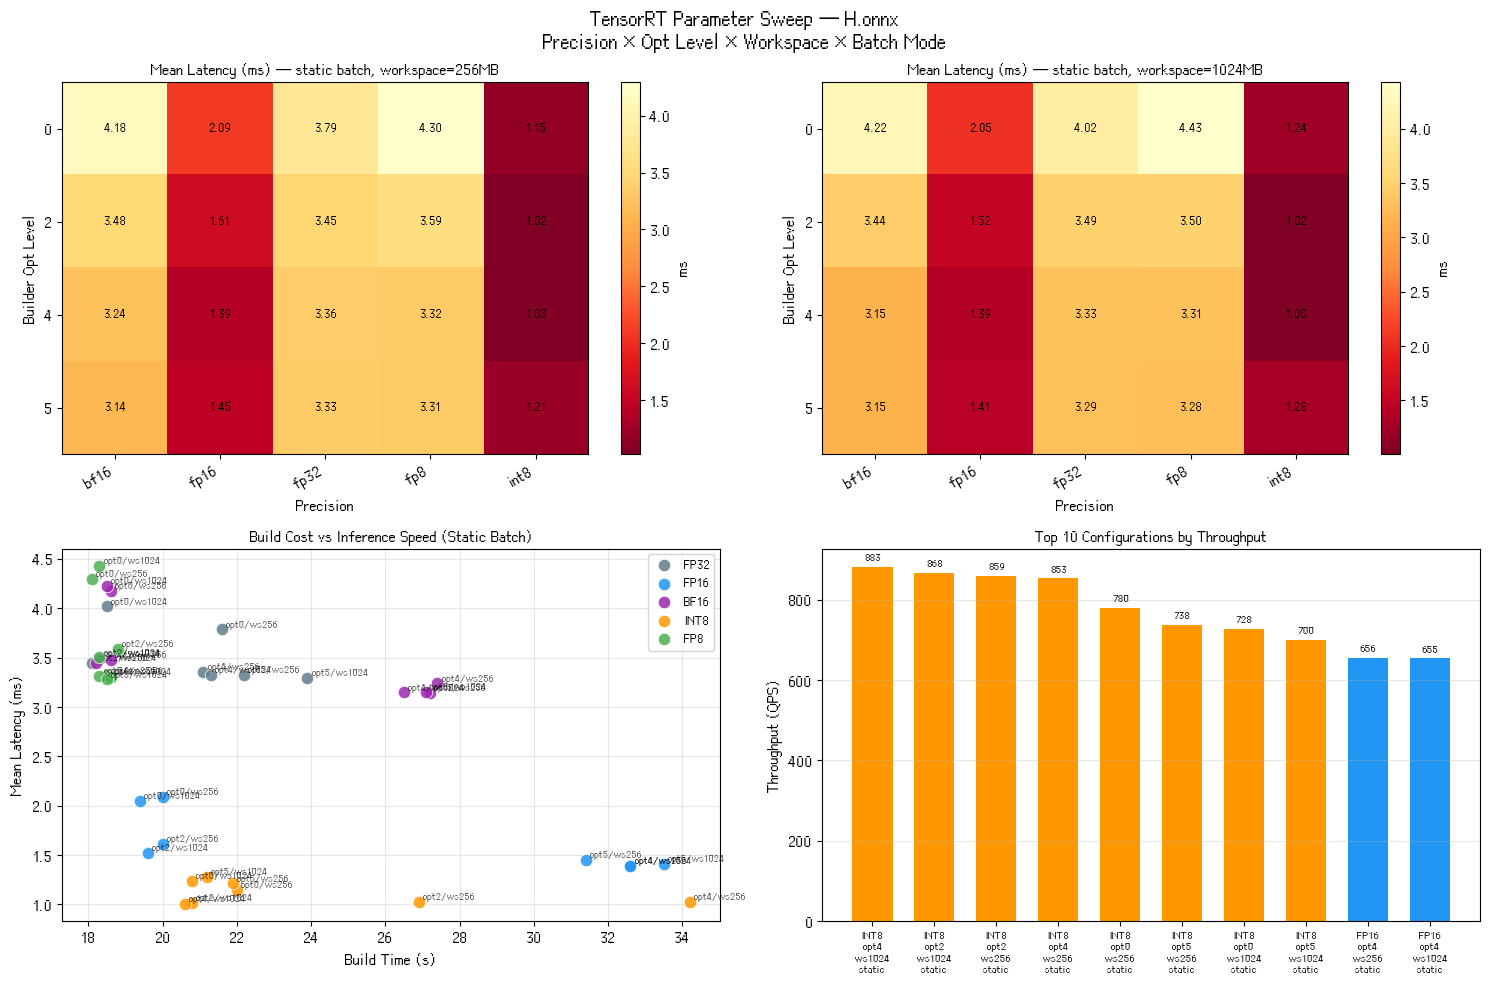

Saved → sweep\sweep_results.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

try:
    import seaborn as sns
    HAS_SNS = True
except ImportError:
    HAS_SNS = False
    print("seaborn not installed — using matplotlib fallback for heatmaps")

# ── 5-precision palette ────────────────────────────────────────────────────
PREC_COLORS = {
    "fp32": "#607D8B",
    "fp16": "#2196F3",
    "bf16": "#9C27B0",
    "int8": "#FF9800",
    "fp8":  "#4CAF50",
}

df_static  = df_ok[df_ok["batch_mode"] == "static"]
df_dynamic = df_ok[df_ok["batch_mode"] == "dynamic"]
ws_groups  = sorted(df_static["workspace_mb"].unique())

has_dynamic = len(df_dynamic) > 0
nrows = 3 if has_dynamic else 2
fig, axes = plt.subplots(nrows, 2, figsize=(15, 5 * nrows))

# ── Row 0: Heatmaps (static batch, one per workspace) ─────────────────────
for col, ws in enumerate(ws_groups[:2]):
    ax  = axes[0, col]
    sub = df_static[df_static["workspace_mb"] == ws]
    pivot = sub.pivot_table(
        index="builder_opt_level", columns="precision", values="mean_ms"
    ).rename_axis(None, axis=1)
    if HAS_SNS:
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd_r",
                    ax=ax, linewidths=0.5, cbar_kws={"label": "ms"})
    else:
        im = ax.imshow(pivot.values, cmap="YlOrRd_r", aspect="auto")
        plt.colorbar(im, ax=ax, label="ms")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        for r in range(pivot.shape[0]):
            for c in range(pivot.shape[1]):
                v = pivot.values[r, c]
                if not np.isnan(v):
                    ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(f"Mean Latency (ms) — static batch, workspace={ws}MB", fontsize=10)
    ax.set_xlabel("Precision")
    ax.set_ylabel("Builder Opt Level")

# ── Row 1, Col 0: Pareto — build time vs latency (static) ─────────────────
ax = axes[1, 0]
for prec in df_static["precision"].unique():
    grp = df_static[df_static["precision"] == prec]
    ax.scatter(
        grp["build_time_s"], grp["mean_ms"],
        c=PREC_COLORS.get(prec, "gray"), label=prec.upper(),
        s=80, alpha=0.85, edgecolors="white", linewidths=0.6, zorder=3
    )
    for _, row in grp.iterrows():
        ax.annotate(
            f"opt{int(row.builder_opt_level)}/ws{int(row.workspace_mb)}",
            (row.build_time_s, row.mean_ms),
            fontsize=6.5, xytext=(3, 2), textcoords="offset points", alpha=0.7
        )
ax.set_xlabel("Build Time (s)")
ax.set_ylabel("Mean Latency (ms)")
ax.set_title("Build Cost vs Inference Speed (Static Batch)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Row 1, Col 1: Top-10 by QPS (all batch modes) ─────────────────────────
ax = axes[1, 1]
top = df_ok.sort_values("throughput_qps", ascending=False).head(10)
bar_labels = top.apply(
    lambda r: f"{r.precision.upper()}\nopt{int(r.builder_opt_level)}\nws{int(r.workspace_mb)}\n{r.batch_mode}",
    axis=1,
)
bar_colors = [PREC_COLORS.get(p, "gray") for p in top["precision"]]
bars = ax.bar(range(len(top)), top["throughput_qps"], color=bar_colors, width=0.65)
ax.set_xticks(range(len(top)))
ax.set_xticklabels(bar_labels, fontsize=7)
ax.set_ylabel("Throughput (QPS)")
ax.set_title("Top 10 Configurations by Throughput", fontsize=10)
ax.grid(axis="y", alpha=0.3)
ymax = top["throughput_qps"].max()
for bar, val in zip(bars, top["throughput_qps"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ymax * 0.01,
            f"{val:.0f}", ha="center", va="bottom", fontsize=7)

# ── Row 2 (optional): Dynamic vs Static comparison ────────────────────────
if has_dynamic:
    ax_dyn = axes[2, 0]
    precs_all = [p for p in ["fp32", "fp16", "bf16", "int8", "fp8"]
                 if p in df_ok["precision"].values]
    compare = []
    for prec in precs_all:
        for bm in ["static", "dynamic"]:
            sub = df_ok[(df_ok["precision"] == prec) & (df_ok["batch_mode"] == bm)]
            if len(sub):
                best_row = sub.loc[sub["mean_ms"].idxmin()]
                compare.append({
                    "precision":      prec,
                    "batch_mode":     bm,
                    "mean_ms":        best_row["mean_ms"],
                    "throughput_qps": best_row.get("throughput_qps", float("nan")),
                })
    df_cmp  = pd.DataFrame(compare)
    precs   = [p for p in precs_all if p in df_cmp["precision"].values]
    x       = np.arange(len(precs))
    w       = 0.35

    def _best(prec, bm):
        v = df_cmp[(df_cmp["precision"] == prec) & (df_cmp["batch_mode"] == bm)]["mean_ms"].values
        return v[0] if len(v) else float("nan")

    s_vals = [_best(p, "static")  for p in precs]
    d_vals = [_best(p, "dynamic") for p in precs]
    colors = [PREC_COLORS.get(p, "gray") for p in precs]

    ax_dyn.bar(x - w / 2, s_vals, w, label="Static (batch=1)",
               color=colors, alpha=0.75, edgecolor="white")
    ax_dyn.bar(x + w / 2, d_vals, w, label=f"Dynamic (opt batch={DYN_OPT_B})",
               color=colors, alpha=1.0, hatch="//", edgecolor="white")
    ax_dyn.set_xticks(x)
    ax_dyn.set_xticklabels([p.upper() for p in precs])
    ax_dyn.set_ylabel("Mean Latency (ms, best config per precision)")
    ax_dyn.set_title("Static vs Dynamic Batch — Best Latency per Precision", fontsize=10)
    ax_dyn.legend(fontsize=8)
    ax_dyn.grid(axis="y", alpha=0.3)

    axes[2, 1].axis("off")

plt.suptitle(
    "TensorRT Parameter Sweep — H.onnx\n"
    "Precision × Opt Level × Workspace × Batch Mode",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()

out_png = SWEEP_DIR / "sweep_results.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_png}")